In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
columnNames = [ 'mpg', 'cylinders',  'displacement', 'horsepower', 'weight',
                 'acceleration', 'model_year', 'origin', 'car_name'] 
df = pd.read_csv( 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data', sep = '\\s+', header = None, names = columnNames, na_values = '?')

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


# EXPLORING THE DATA AND CLEANING IT 



In [3]:
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    str    
dtypes: float64(5), int64(3), str(1)
memory usage: 28.1 KB


mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [4]:

df = df.dropna().reset_index(drop=True)
df = df.drop( columns = 'car_name')
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


# Plotting each feature against mpg to get a feel of what the relationship between them is

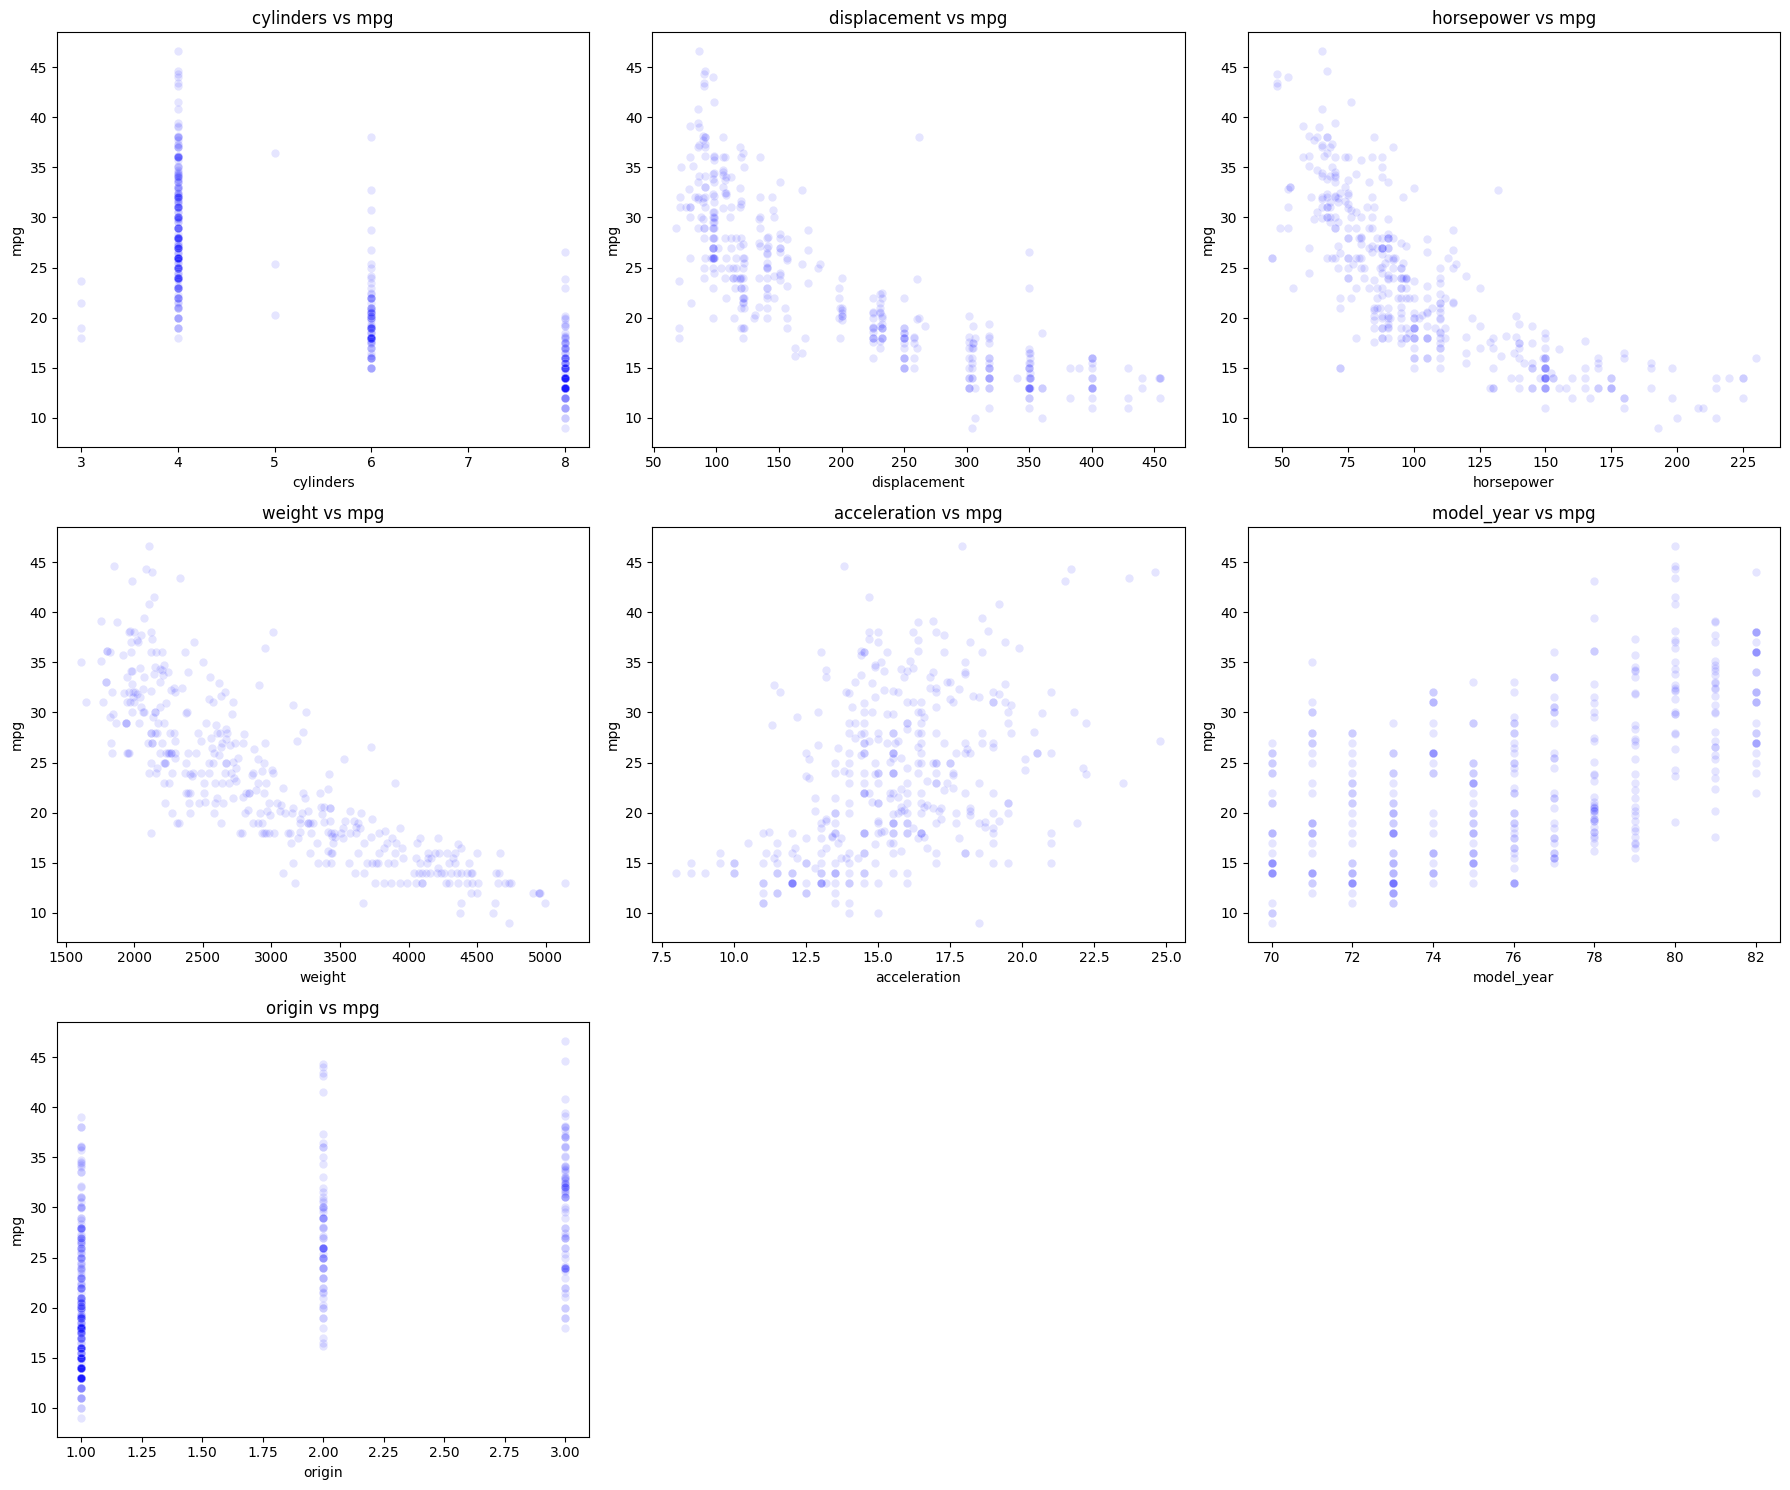

In [ ]:
dfSample =  df
target = 'mpg'
features = [ col for col in df.columns if col != target ] #list comprehnsion that grabs every col name except target and stores them as strings
nCols = 3
nRows = (len ( features ) + nCols - 1) // nCols
fig, axes = plt.subplots( nRows, nCols, figsize = ( 18, 5 * nRows ) ) #create figure and grid of subplots, each sozed so that each row is five inches 
# tall, and 18 inches wide
axes = axes.flatten() # for easier access as flattem return a list with indeces (3,3) this makes us able to move thtough it with one index
for i, feature in enumerate(features):
    sns.scatterplot( data = dfSample, x = feature, y = targer, alpha = 0.1, ax = axes[i], color = 'blue' )
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_ylabel( 'mpg' )
    axes[i].set_xlabel( feature )
for  j in range( i + 1, len( axes )): #after loop we end up at i = last element  so remove all plots that are unused
    fig.delaxes(axes[j]) 
plt.tight_layout()
plt.show()

since origin is discrete value that enocodes the country, it doesnt actually contain any numeric info ( the higher the number does mean anything specifically) we will hot encode it to ensure our model behaves well

In [10]:
df = pd.get_dummies(df, columns=['origin'], prefix='origin', drop_first=True)


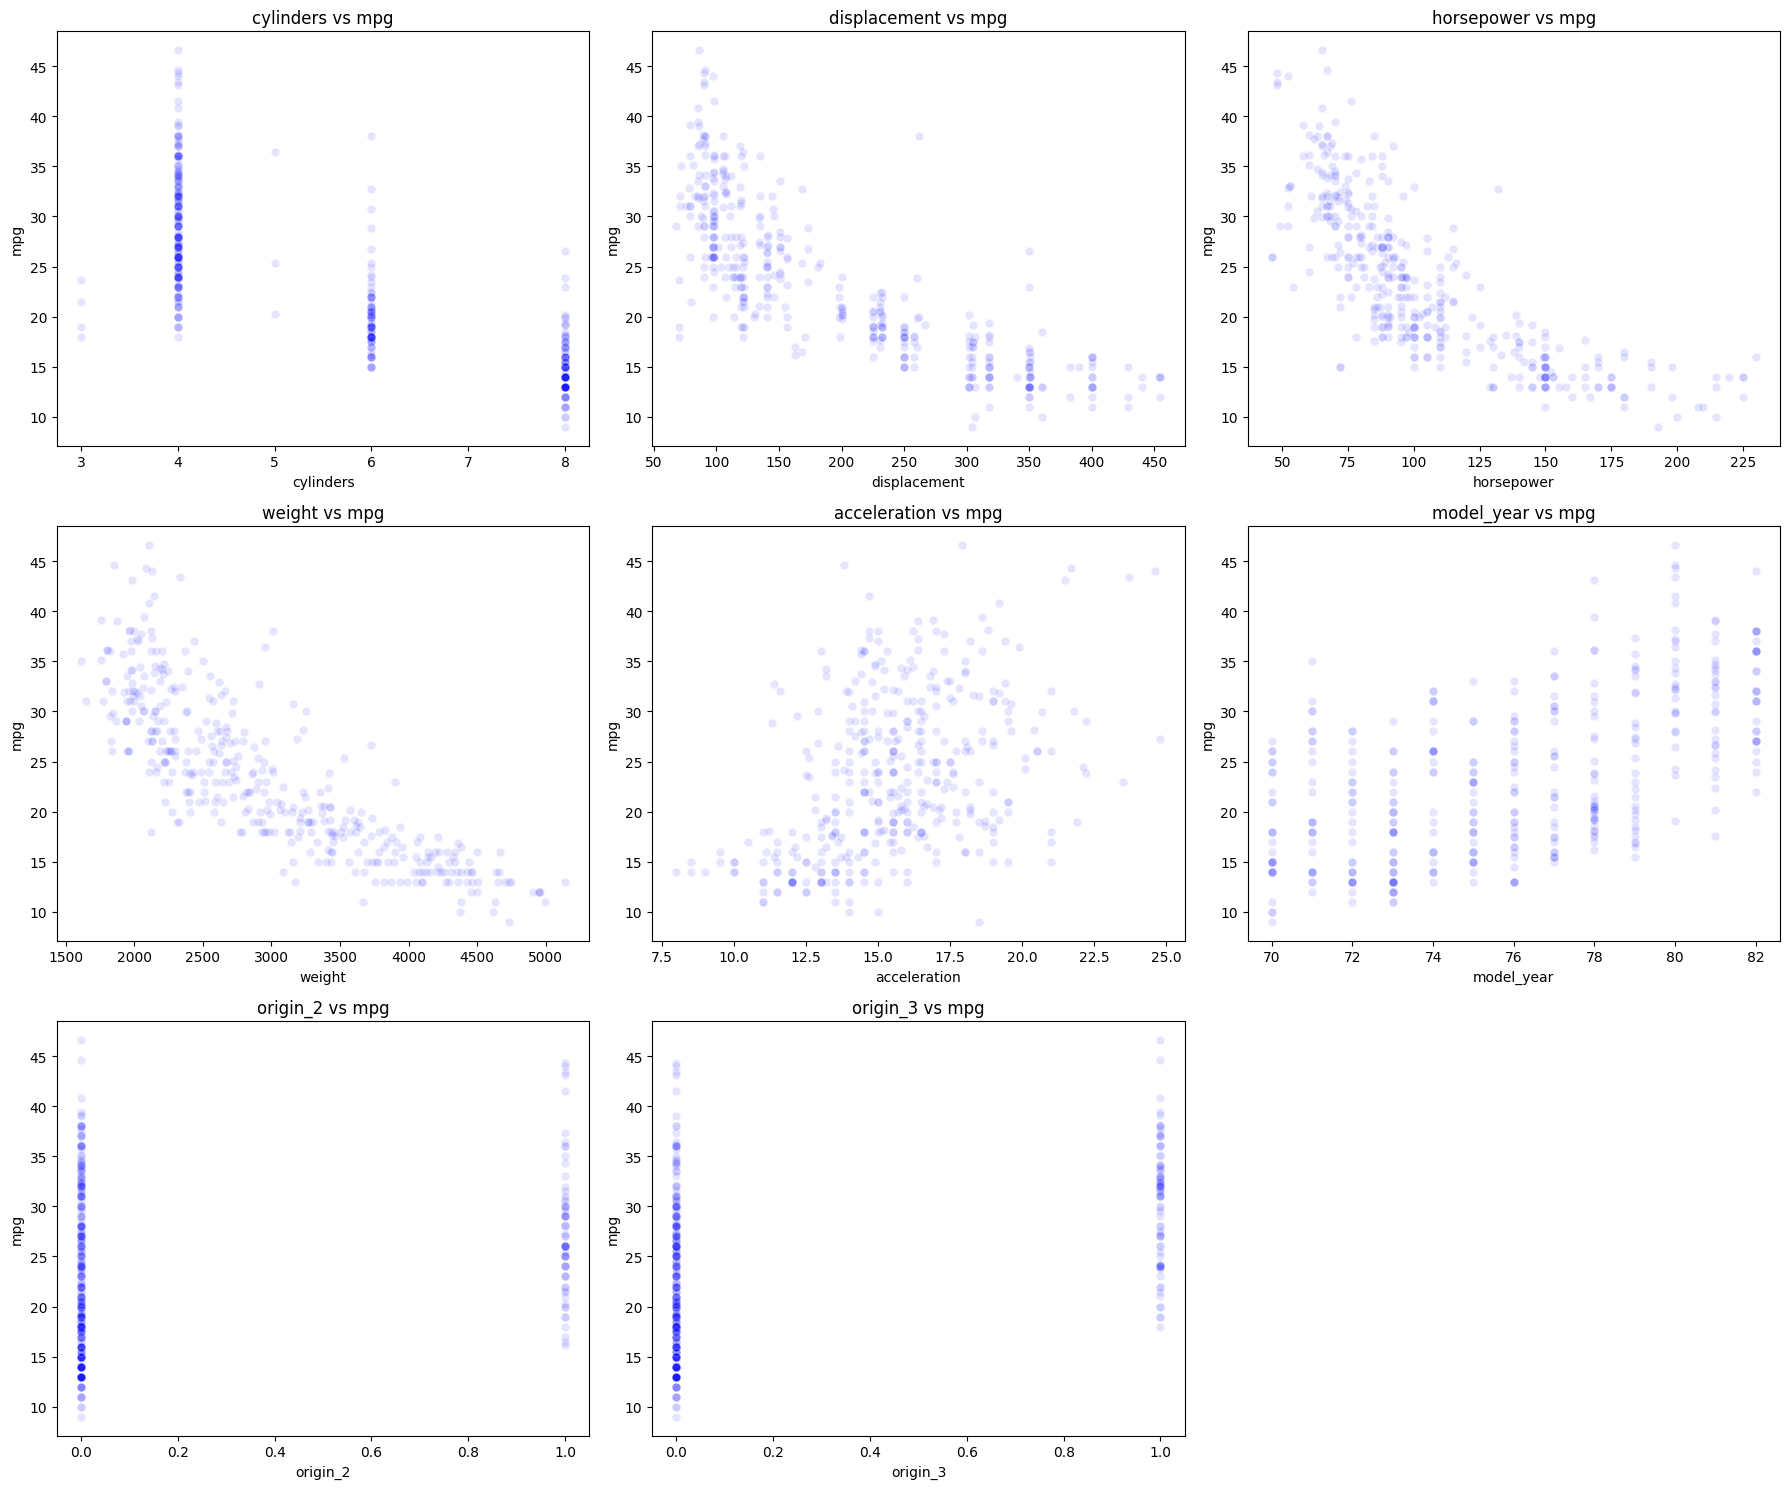

In [11]:
dfSample =  df
target = 'mpg'
features = [ col for col in df.columns if col != target ] #list comprehnsion that grabs every col name except target and stores them as strings
nCols = 3
nRows = (len ( features ) + nCols - 1) // nCols
fig, axes = plt.subplots( nRows, nCols, figsize = ( 18, 5 * nRows ) ) #create figure and grid of subplots, each sozed so that each row is five inches 
# tall, and 18 inches wide
axes = axes.flatten() # for easier access as flattem return a list with indeces (3,3) this makes us able to move thtough it with one index
for i, feature in enumerate(features):
    sns.scatterplot( data = dfSample, x = feature, y = targer, alpha = 0.1, ax = axes[i], color = 'blue' )
    axes[i].set_title(f'{feature} vs {target}')
    axes[i].set_ylabel( 'mpg' )
    axes[i].set_xlabel( feature )
for  j in range( i + 1, len( axes )): #after loop we end up at i = last element  so remove all plots that are unused
    fig.delaxes(axes[j]) 
plt.tight_layout()
plt.show()

# NOW , as we can see horsepower, weight and displacement exhibit the behaviour of a poly of a higher degree

-now we will save our data to be able to access it later when training the models

In [ ]:
df.to_csv('uber_processed.csv', index=False)

: 